In [1]:
import torch
import torchvision.datasets as dests
import torchvision.transforms as transforms
import torch.nn.init
import matplotlib.pyplot as plt

In [2]:
# Cuda 선언
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 랜덤 시드 고정
torch.manual_seed(777)

# GPU 사용 가능일 경우 랜덤 시드 고정
if device == 'cuda':
    torch.cuda.manual_seed_all(777)
    print('cuda')

cuda


In [3]:
# 학습 파라미터 설정
learning_rate = 0.001
training_epochs = 20
batch_size = 100

In [9]:
# 데이터셋 정의 (Data Augmentation 추가)
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

cifar_train = dests.CIFAR10(root ='/Users/mbnv6/Project/dataset/CIFAR10_data',
                            train = True,
                            transform= transform_train,
                            download = False)
cifar_test = dests.CIFAR10(root = '/Users/mbnv6/Project/dataset/CIFAR10_data',
                           train = False,
                           transform= transform_test,
                           download = False)

In [10]:
data_loader = torch.utils.data.DataLoader(dataset = cifar_train,
                                          batch_size = batch_size,
                                          shuffle = True,
                                          drop_last = True)

In [11]:
# 데이터셋 크기 확인
print(f'학습 데이터 개수: {len(cifar_train)}')
print(f'테스트 데이터 개수: {len(cifar_test)}')
print(f'이미지 형태: {cifar_train[0][0].shape}')
print(f'배치 개수: {len(data_loader)}')

학습 데이터 개수: 50000
테스트 데이터 개수: 10000
이미지 형태: torch.Size([3, 32, 32])
배치 개수: 500


배치 이미지 shape: torch.Size([100, 3, 32, 32])
배치 라벨 shape: torch.Size([100])
이미지 데이터 타입: torch.float32
이미지 값의 범위: [-2.4291, 2.7537]


C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\3189825898.py:33: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\3189825898.py:33: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\3189825898.py:33: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\3189825898.py:33: UserWarning: Glyph 49483 (\N{HANGUL SYLLABLE SES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\3189825898.py:33: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\3189825898.py:33: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from 

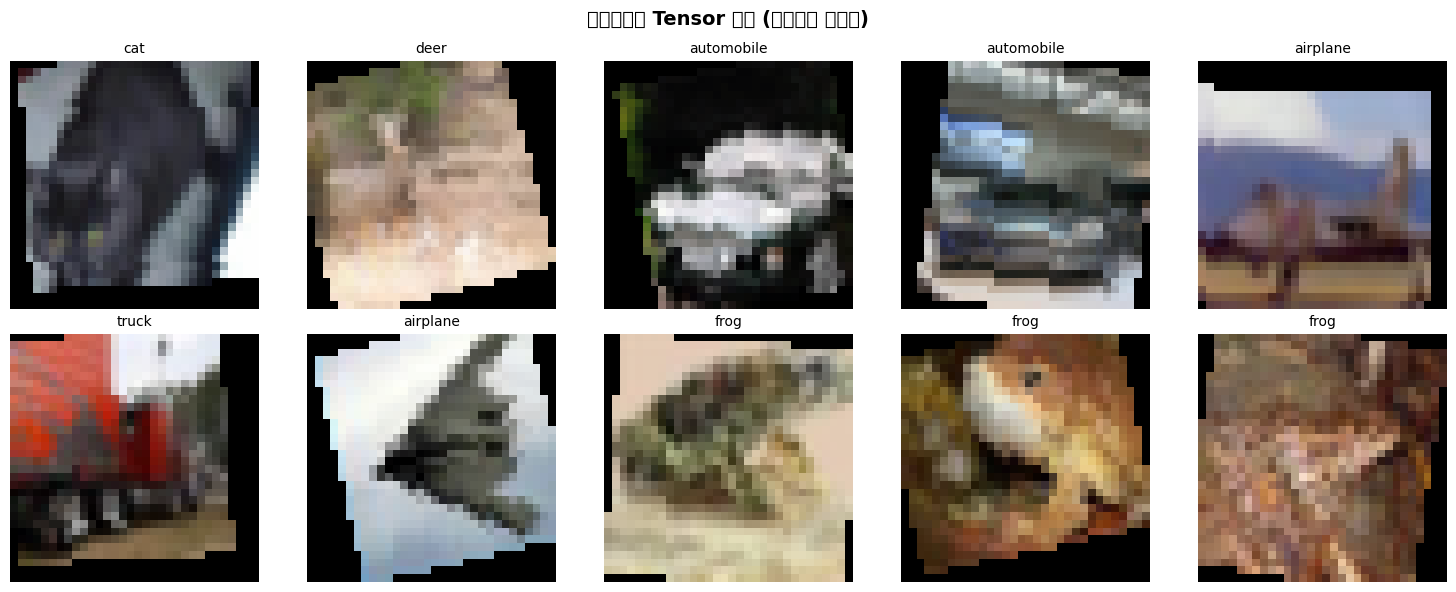


첫 번째 이미지의 Tensor 값 샘플 (정규화됨):
채널 0: tensor([[-2.4291, -2.4291, -2.4291],
        [-2.4291, -1.4598, -1.4598],
        [-2.4291, -0.7426, -0.4324]])
채널 1: tensor([[-2.4183, -2.4183, -2.4183],
        [-2.4183, -2.0643, -1.9463],
        [-2.4183, -1.2186, -0.3926]])
채널 2: tensor([[-2.2214, -2.2214, -2.2214],
        [-2.2214, -1.8117, -1.6166],
        [-2.2214, -0.8947, -0.1338]])


In [12]:
# 데이터셋을 Tensor로 변환한 것 시각화
import numpy as np

# 한 배치의 데이터 가져오기
sample_images, sample_labels = next(iter(data_loader))

print(f"배치 이미지 shape: {sample_images.shape}")
print(f"배치 라벨 shape: {sample_labels.shape}")
print(f"이미지 데이터 타입: {sample_images.dtype}")
print(f"이미지 값의 범위: [{sample_images.min():.4f}, {sample_images.max():.4f}]")

# 원본 이미지와 정규화된 이미지 비교
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('데이터셋의 Tensor 변환 (정규화된 이미지)', fontsize=14, fontweight='bold')

cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# 정규화 역함수
mean = np.array([0.4914, 0.4822, 0.4465])
std = np.array([0.2023, 0.1994, 0.2010])

for i in range(10):
    # 정규화된 이미지
    ax = axes[0, i % 5] if i < 5 else axes[1, i % 5]
    img = sample_images[i].cpu().numpy().transpose(1, 2, 0)
    # 역정규화
    img = img * std + mean
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(f'{cifar_classes[sample_labels[i].item()]}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"\n첫 번째 이미지의 Tensor 값 샘플 (정규화됨):")
print(f"채널 0: {sample_images[0, 0, :3, :3]}")
print(f"채널 1: {sample_images[0, 1, :3, :3]}")
print(f"채널 2: {sample_images[0, 2, :3, :3]}")

In [13]:
class CNN(torch.nn.Module):
    def __init__(self):
        super(CNN,self).__init__()
        self.keep_prob = 0.7 # 드롭아웃 확률 (과적합 방지 강화)
        # input image 형태는 (32, 32 , 3 ) # 높이 폭 채널
        # Conv2d 로 출력채널 32개, stride = 1, padding = 1으로 convolution 후의 크기를 보정해줌
        # ReLU = Activation Function
        # MaxPool2d = Kernel size 2x2, stride 2로 down sampling ->> 출력 형태는 (16,16,32)
        self.layer1 = torch.nn.Sequential(
            torch.nn.Conv2d(3, 32, kernel_size= 3, stride= 1, padding = 1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size = 2, stride = 2)
        ) 
        # input 형태는 (16, 16, 32) 
        # Conv2d로 출력채널 64개
        # MaxPool2d 로 down sampling ->> 출력은 8,8,64
        self.layer2 = torch.nn.Sequential(
            torch.nn.Conv2d(32, 64, kernel_size= 3, stride= 1, padding = 1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size = 2, stride =2)
        )
        # input는 8,8,64
        # Conv2d로 출력채널 128개
        # Maxpool2d로 down sampling ->> 출력은 4,4,128
        self.layer3 = torch.nn.Sequential(
            torch.nn.Conv2d(64, 128, kernel_size= 3, stride= 1, padding = 1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size= 2, stride= 2)
        )
        # Fully Connected Layer 1
        # input node = 4x4x128 = 2048, 출력노드는 625 
        # Drop out으로 과적합 방지, p = 0.5
        self.fc1 = torch.nn.Linear(4 * 4 * 128, 625, bias = True)
        torch.nn.init.xavier_uniform_(self.fc1.weight)
        self.layer4 = torch.nn.Sequential(
            self.fc1,
            torch.nn.ReLU(),
            torch.nn.Dropout(p= 1- self.keep_prob)
        )

        # 최종 FC layer
        # input node = 625, 출력 10
        self.fc2 = torch.nn.Linear(625, 10, bias= True)
        torch.nn.init.xavier_uniform_(self.fc2.weight)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        # fc layer 전에 Tensor 펼치기
        out = out.view(out.size(0),-1)
        out = self.layer4(out)
        out = self.fc2(out)
        return out

In [15]:
# 모델 정의
model = CNN().to(device)

Convolution 신경망 구조 분석

입력 이미지 shape: torch.Size([4, 3, 32, 32])
Layer1 (Conv 3->32 + ReLU + MaxPool) 출력: torch.Size([4, 32, 16, 16])
Layer2 (Conv 32->64 + ReLU + MaxPool) 출력: torch.Size([4, 64, 8, 8])
Layer3 (Conv 64->128 + ReLU + MaxPool) 출력: torch.Size([4, 128, 4, 4])


C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\4252545355.py:62: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\4252545355.py:62: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\4252545355.py:62: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\4252545355.py:62: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\4252545355.py:62: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\4252545355.py:62: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing from f

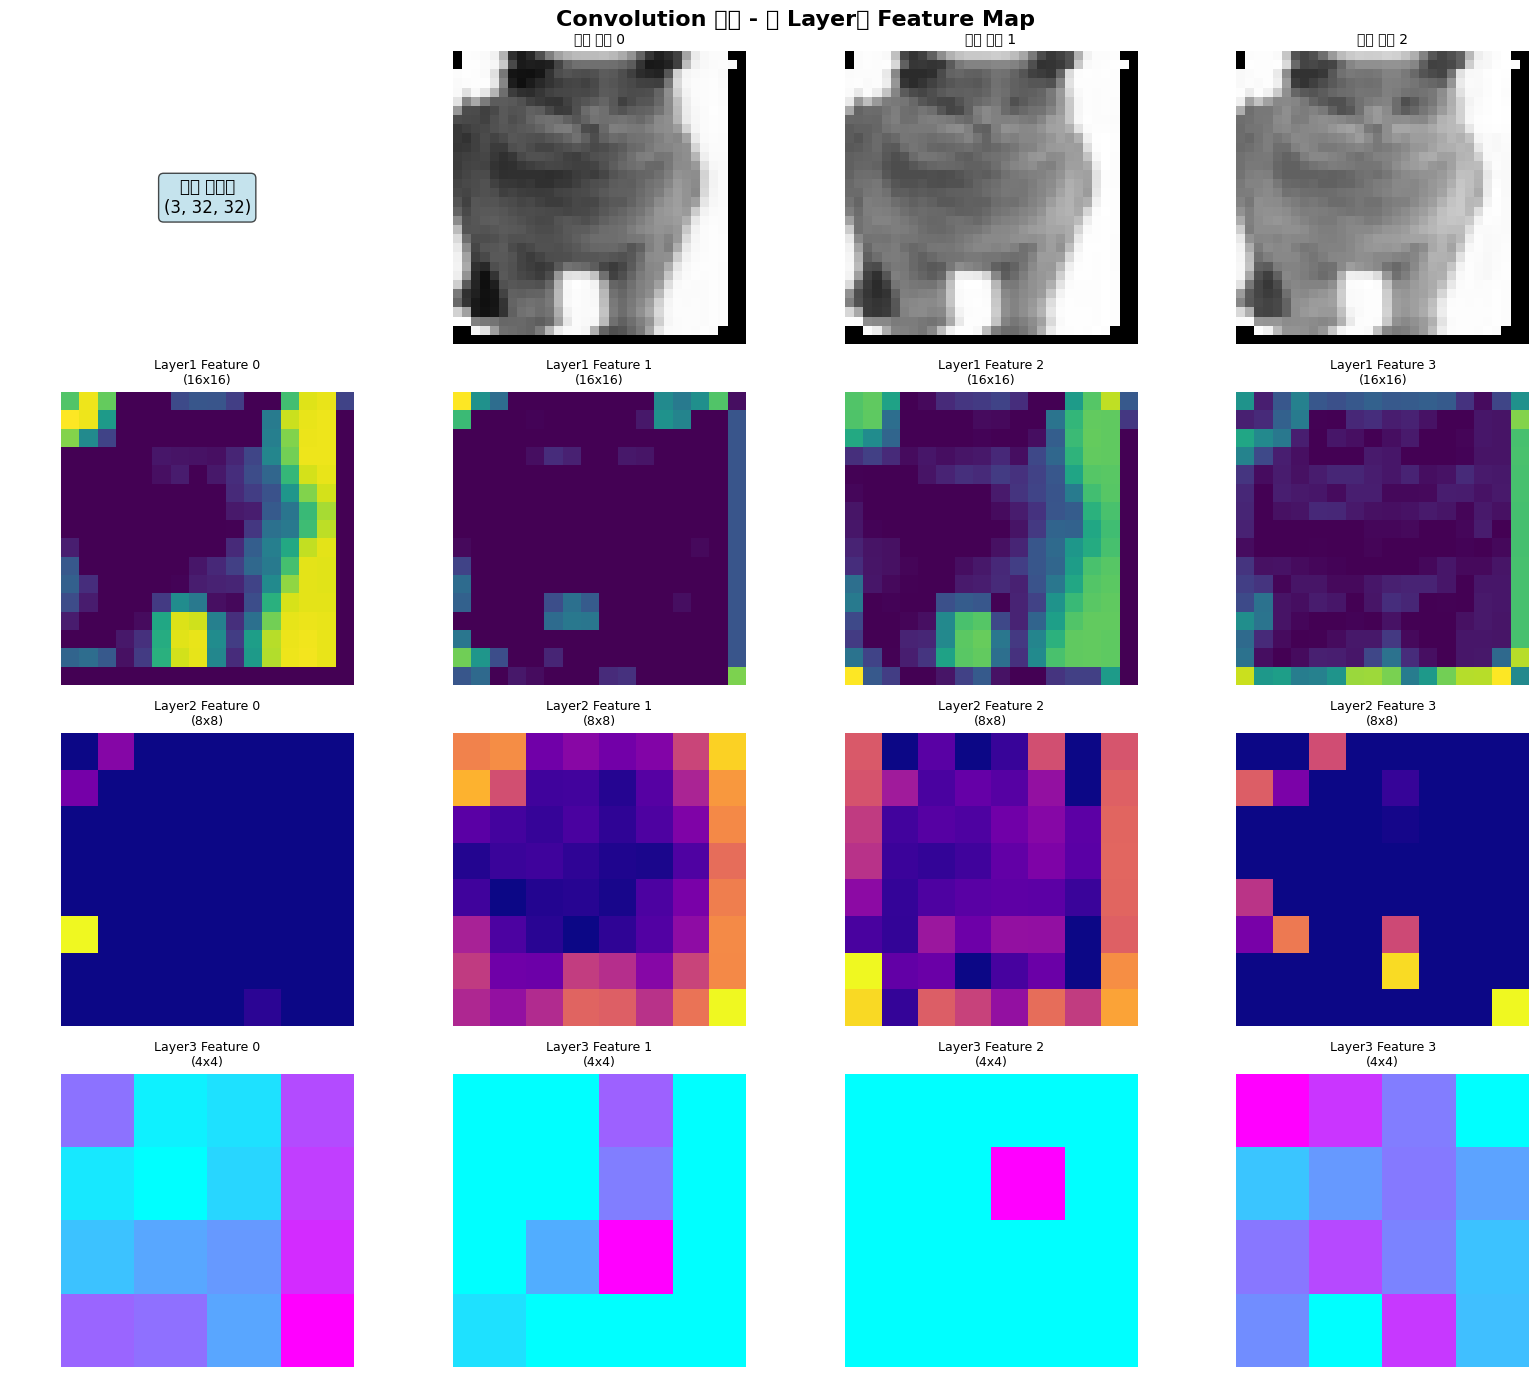


✓ Convolution 과정 시각화 완료


In [17]:
# Convolution 과정 시각화 - 모델 구성 후에 실행
print("=" * 60)
print("Convolution 신경망 구조 분석")
print("=" * 60)

# 샘플 이미지로 forward pass 하면서 각 layer의 출력 확인
sample_input, _ = next(iter(data_loader))
sample_input = sample_input[:4].to(device)  # 4개 이미지만 사용

print(f"\n입력 이미지 shape: {sample_input.shape}")

# Layer별 출력 추적
with torch.no_grad():
    # Layer 1: Conv(3->32) + ReLU + MaxPool
    out1 = model.layer1(sample_input)
    print(f"Layer1 (Conv 3->32 + ReLU + MaxPool) 출력: {out1.shape}")
    
    # Layer 2: Conv(32->64) + ReLU + MaxPool
    out2 = model.layer2(out1)
    print(f"Layer2 (Conv 32->64 + ReLU + MaxPool) 출력: {out2.shape}")
    
    # Layer 3: Conv(64->128) + ReLU + MaxPool
    out3 = model.layer3(out2)
    print(f"Layer3 (Conv 64->128 + ReLU + MaxPool) 출력: {out3.shape}")

# Convolution 과정 시각화
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
fig.suptitle('Convolution 과정 - 각 Layer의 Feature Map', fontsize=16, fontweight='bold')

# Layer 1 출력 시각화 (처음 4개 필터의 결과)
axes[0, 0].text(0.5, 0.5, '입력 이미지\n(3, 32, 32)', ha='center', va='center', fontsize=12, 
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
axes[0, 0].axis('off')

for i in range(3):
    img = sample_input[0, i].cpu().numpy()
    axes[0, i+1].imshow(img, cmap='gray')
    axes[0, i+1].set_title(f'입력 채널 {i}', fontsize=10)
    axes[0, i+1].axis('off')

# Layer 1 Feature maps (32 channels 중 4개)
for i in range(4):
    feature_map = out1[0, i].cpu().numpy()
    axes[1, i].imshow(feature_map, cmap='viridis')
    axes[1, i].set_title(f'Layer1 Feature {i}\n(16x16)', fontsize=9)
    axes[1, i].axis('off')

# Layer 2 Feature maps (64 channels 중 4개)
for i in range(4):
    feature_map = out2[0, i].cpu().numpy()
    axes[2, i].imshow(feature_map, cmap='plasma')
    axes[2, i].set_title(f'Layer2 Feature {i}\n(8x8)', fontsize=9)
    axes[2, i].axis('off')

# Layer 3 Feature maps (128 channels 중 4개)
for i in range(4):
    feature_map = out3[0, i].cpu().numpy()
    axes[3, i].imshow(feature_map, cmap='cool')
    axes[3, i].set_title(f'Layer3 Feature {i}\n(4x4)', fontsize=9)
    axes[3, i].axis('off')

plt.tight_layout()
plt.show()

print("\n✓ Convolution 과정 시각화 완료")

CNN Kernel 초기값 분석 (Xavier Initialization)

Layer 1 Conv Kernel shape: (32, 3, 3, 3)
  - 출력 채널: 32, 입력 채널: 3, 커널 크기: 3x3


C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\3981119603.py:24: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\3981119603.py:24: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\3981119603.py:24: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\3981119603.py:24: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\3981119603.py:24: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\3981119603.py:24: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from 

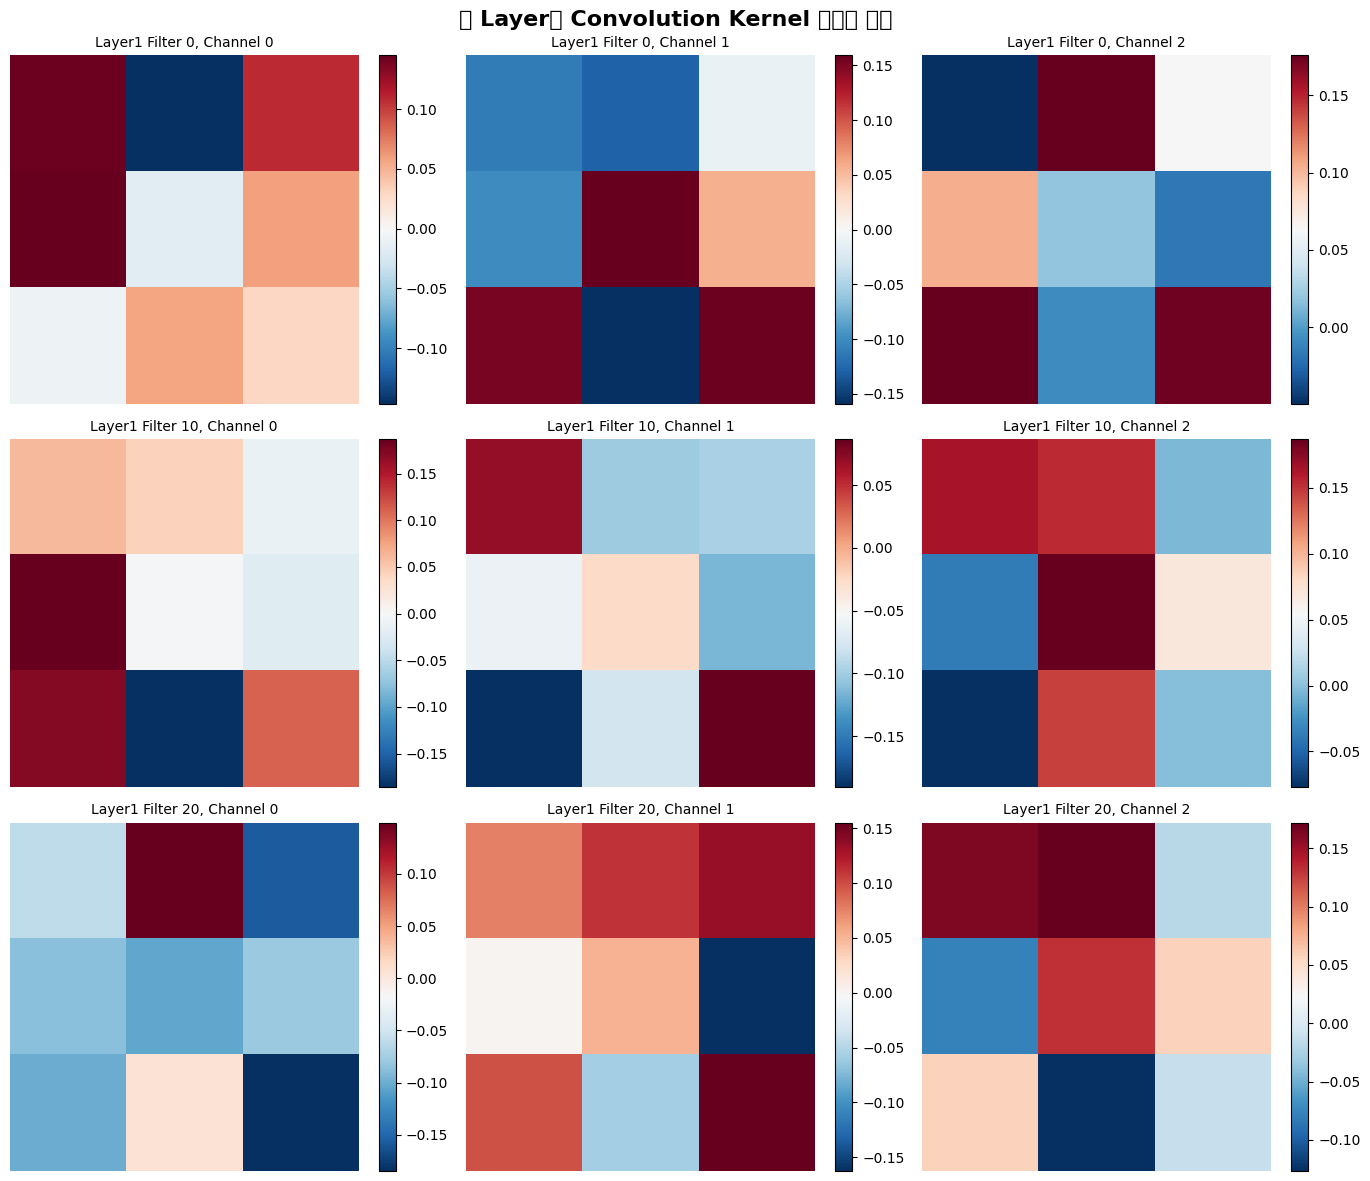


Layer 2 Conv Kernel shape: (64, 32, 3, 3)
  - 출력 채널: 64, 입력 채널: 32, 커널 크기: 3x3


C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\3981119603.py:44: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\3981119603.py:44: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\3981119603.py:44: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\3981119603.py:44: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\3981119603.py:44: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\3981119603.py:44: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing 

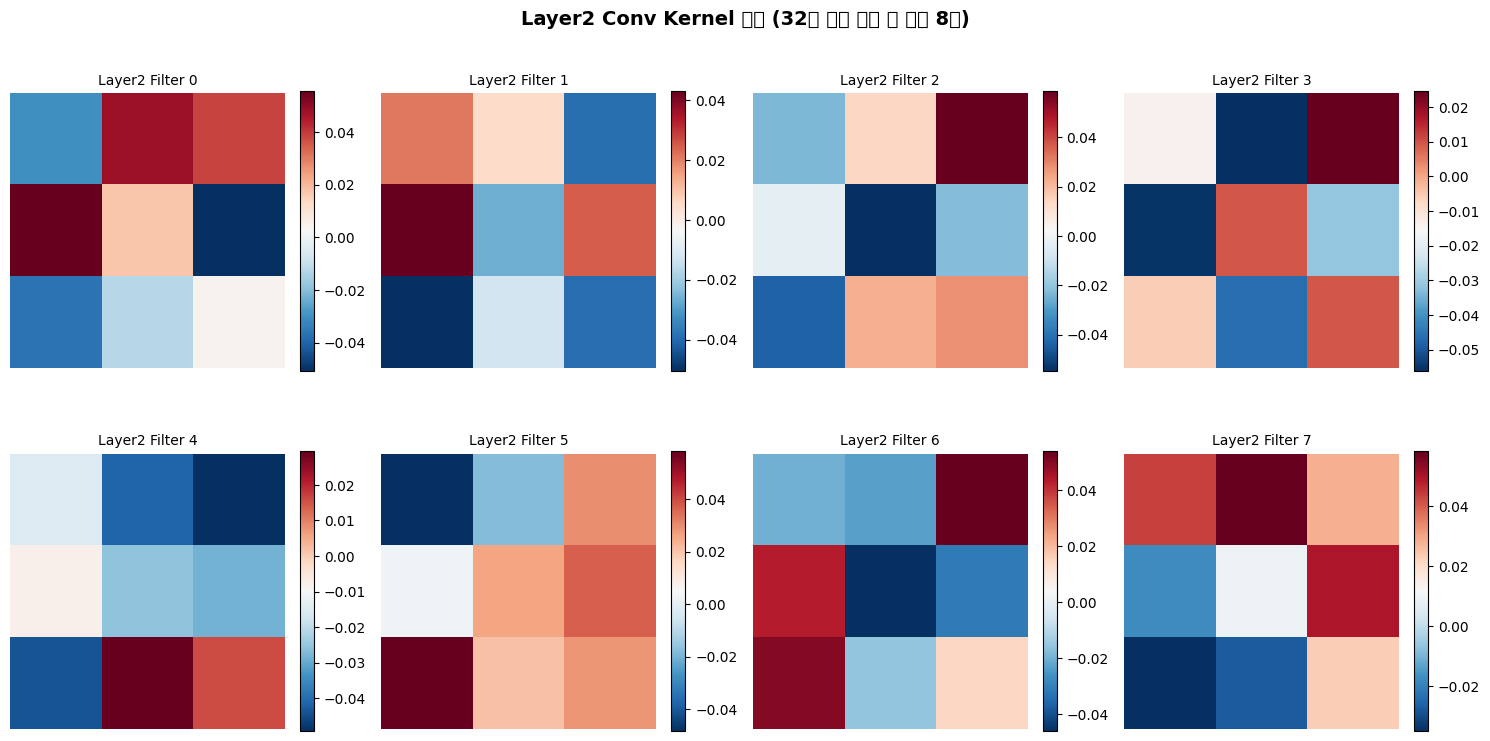

Layer1 Kernel 통계: μ=0.001881, σ=0.106818
Layer2 Kernel 통계: μ=0.000614, σ=0.034183
Layer3 Kernel 통계: μ=-0.000083, σ=0.024024


C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\3981119603.py:78: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\3981119603.py:78: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\3981119603.py:78: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\3981119603.py:78: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\3981119603.py:78: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\3981119603.py:78: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from

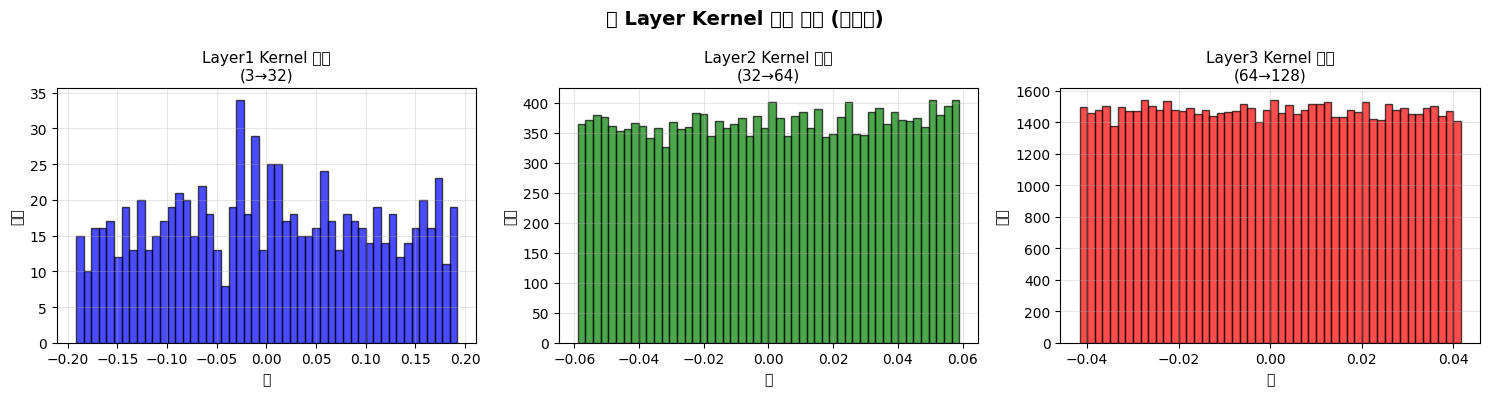


✓ Kernel 초기값 시각화 완료


In [18]:
# Kernel의 초기값 시각화
print("=" * 60)
print("CNN Kernel 초기값 분석 (Xavier Initialization)")
print("=" * 60)

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
fig.suptitle('각 Layer의 Convolution Kernel 초기값 분포', fontsize=16, fontweight='bold')

# Layer 1 Conv 커널 분석
conv1_weight = model.layer1[0].weight.data.cpu().numpy()  # shape: (32, 3, 3, 3)
print(f"\nLayer 1 Conv Kernel shape: {conv1_weight.shape}")
print(f"  - 출력 채널: 32, 입력 채널: 3, 커널 크기: 3x3")

# 첫 4개 필터의 3개 채널 시각화
for out_ch in range(3):
    for in_ch in range(3):
        ax = axes[out_ch, in_ch]
        kernel = conv1_weight[out_ch * 10, in_ch]  # 각 필터의 입력 채널별 커널
        im = ax.imshow(kernel, cmap='RdBu_r')
        ax.set_title(f'Layer1 Filter {out_ch*10}, Channel {in_ch}', fontsize=10)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

# Layer 2 Conv 커널 분석
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
fig.suptitle('Layer2 Conv Kernel 샘플 (32개 입력 채널 중 처음 8개)', fontsize=14, fontweight='bold')

conv2_weight = model.layer1[0].weight.data.cpu().numpy() if hasattr(model.layer2[0], 'weight') else None
conv2_actual = model.layer2[0].weight.data.cpu().numpy()  # shape: (64, 32, 3, 3)
print(f"\nLayer 2 Conv Kernel shape: {conv2_actual.shape}")
print(f"  - 출력 채널: 64, 입력 채널: 32, 커널 크기: 3x3")

for i in range(8):
    ax = axes[i // 4, i % 4]
    kernel = conv2_actual[i, 0]  # 첫 번째 필터, 첫 번째 입력 채널
    im = ax.imshow(kernel, cmap='RdBu_r')
    ax.set_title(f'Layer2 Filter {i}', fontsize=10)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

# Kernel 값 분포 히스토그램
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('각 Layer Kernel 값의 분포 (초기값)', fontsize=14, fontweight='bold')

# Layer 1
conv1_weight_flat = model.layer1[0].weight.data.cpu().numpy().flatten()
axes[0].hist(conv1_weight_flat, bins=50, color='blue', alpha=0.7, edgecolor='black')
axes[0].set_title('Layer1 Kernel 분포\n(3→32)', fontsize=11)
axes[0].set_xlabel('값')
axes[0].set_ylabel('빈도')
axes[0].grid(True, alpha=0.3)
print(f"Layer1 Kernel 통계: μ={conv1_weight_flat.mean():.6f}, σ={conv1_weight_flat.std():.6f}")

# Layer 2
conv2_weight_flat = model.layer2[0].weight.data.cpu().numpy().flatten()
axes[1].hist(conv2_weight_flat, bins=50, color='green', alpha=0.7, edgecolor='black')
axes[1].set_title('Layer2 Kernel 분포\n(32→64)', fontsize=11)
axes[1].set_xlabel('값')
axes[1].set_ylabel('빈도')
axes[1].grid(True, alpha=0.3)
print(f"Layer2 Kernel 통계: μ={conv2_weight_flat.mean():.6f}, σ={conv2_weight_flat.std():.6f}")

# Layer 3
conv3_weight_flat = model.layer3[0].weight.data.cpu().numpy().flatten()
axes[2].hist(conv3_weight_flat, bins=50, color='red', alpha=0.7, edgecolor='black')
axes[2].set_title('Layer3 Kernel 분포\n(64→128)', fontsize=11)
axes[2].set_xlabel('값')
axes[2].set_ylabel('빈도')
axes[2].grid(True, alpha=0.3)
print(f"Layer3 Kernel 통계: μ={conv3_weight_flat.mean():.6f}, σ={conv3_weight_flat.std():.6f}")

plt.tight_layout()
plt.show()

print("\n✓ Kernel 초기값 시각화 완료")

In [19]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr= learning_rate, weight_decay=1e-4)  # Weight Decay 추가

MaxPool2D 과정 시각화

Layer1 Conv + ReLU 출력: torch.Size([2, 32, 32, 32])
Layer1 (MaxPool 포함) 출력: torch.Size([2, 32, 16, 16])
Layer2 Conv + ReLU 출력: torch.Size([2, 64, 16, 16])
Layer2 (MaxPool 포함) 출력: torch.Size([2, 64, 8, 8])
Layer3 Conv + ReLU 출력: torch.Size([2, 128, 8, 8])
Layer3 (MaxPool 포함) 출력: torch.Size([2, 128, 4, 4])


C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\2713811420.py:71: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\2713811420.py:71: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\2713811420.py:71: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\2713811420.py:71: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\2713811420.py:71: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\2713811420.py:71: UserWarning: Glyph 50868 (\N{HANGUL SYLLABLE UN}) missing from fo

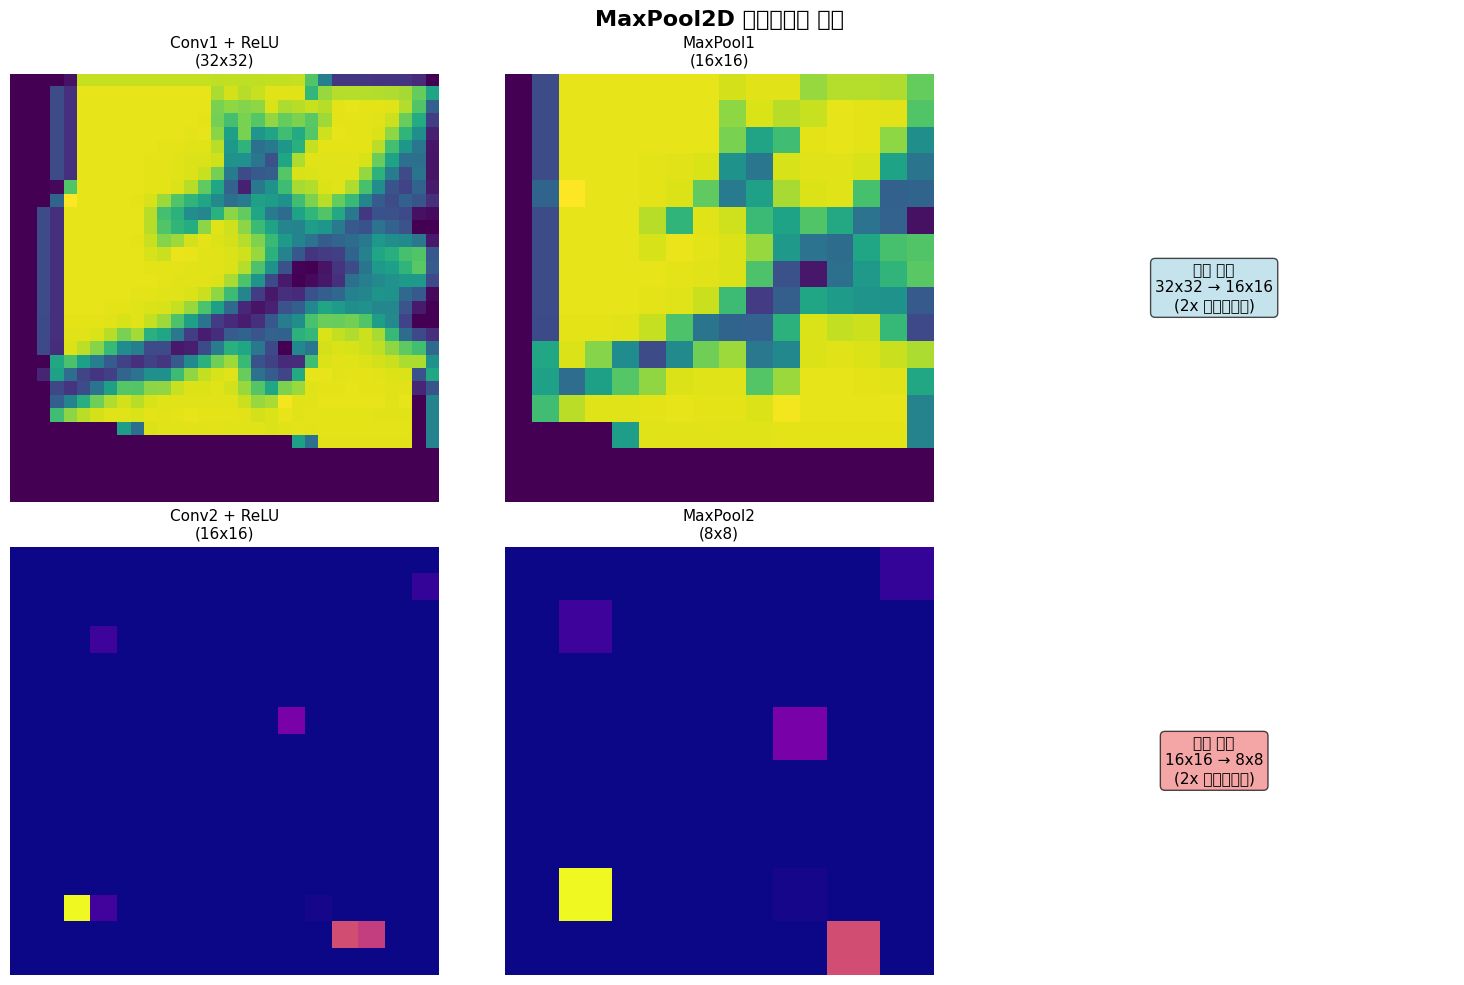

C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\2713811420.py:90: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\2713811420.py:90: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\2713811420.py:90: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\2713811420.py:90: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\2713811420.py:90: UserWarning: Glyph 45328 (\N{HANGUL SYLLABLE NEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\mbnv6\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) m

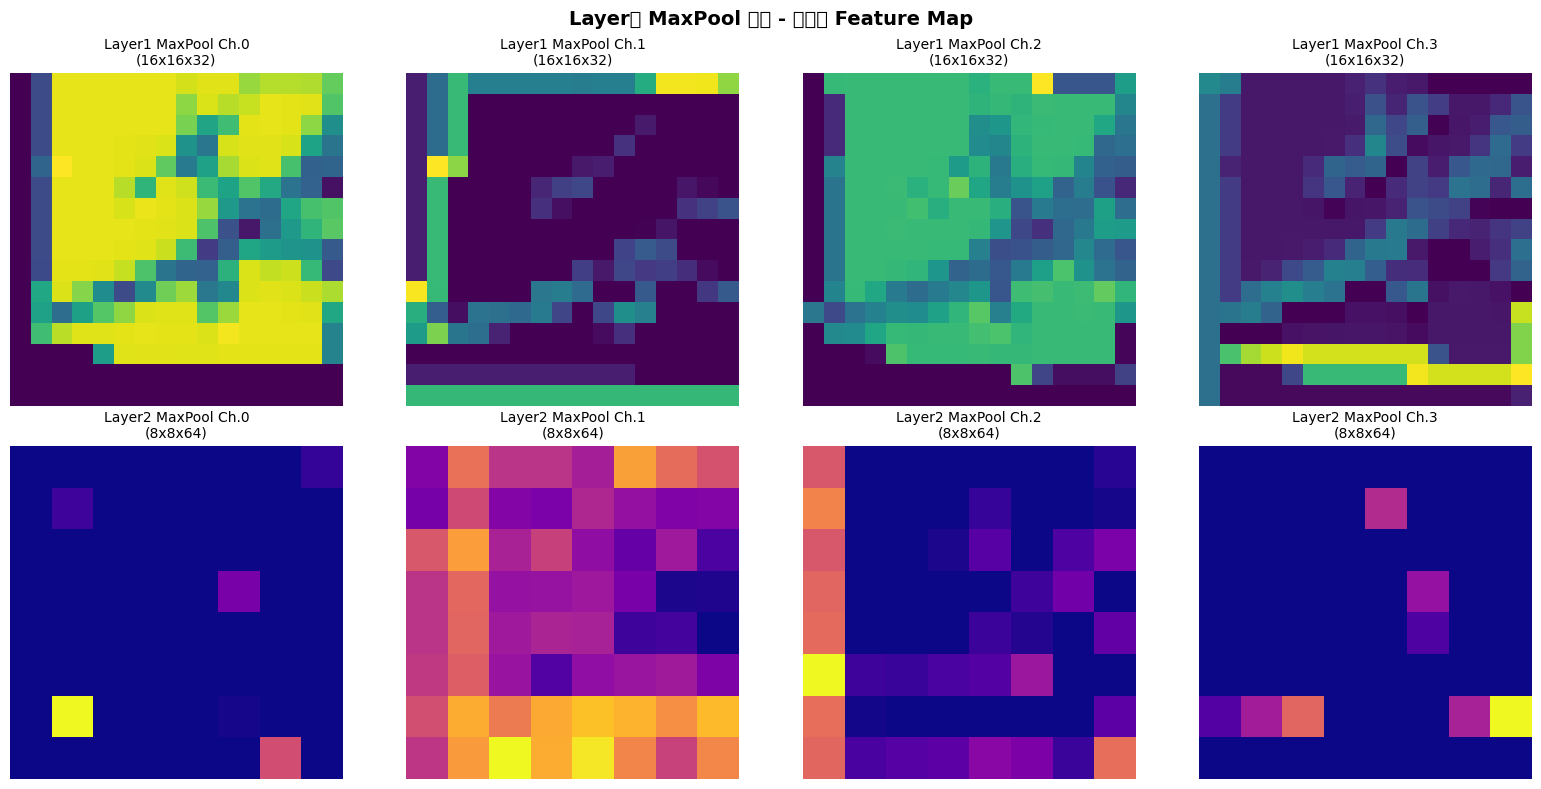


✓ MaxPool2D 시각화 완료


In [20]:
# MaxPool2D 출력 시각화
print("=" * 60)
print("MaxPool2D 과정 시각화")
print("=" * 60)

# Conv 출력과 MaxPool 출력 비교
sample_input, _ = next(iter(data_loader))
sample_input = sample_input[:2].to(device)

with torch.no_grad():
    # Layer 1 Conv + ReLU (MaxPool 전)
    conv1_relu = model.layer1[0:2](sample_input)  # Conv + ReLU만
    print(f"\nLayer1 Conv + ReLU 출력: {conv1_relu.shape}")
    
    # Layer 1 전체 (MaxPool 포함)
    layer1_out = model.layer1(sample_input)
    print(f"Layer1 (MaxPool 포함) 출력: {layer1_out.shape}")
    
    # Layer 2 Conv + ReLU
    conv2_relu = model.layer2[0:2](layer1_out)
    print(f"Layer2 Conv + ReLU 출력: {conv2_relu.shape}")
    
    # Layer 2 전체
    layer2_out = model.layer2(layer1_out)
    print(f"Layer2 (MaxPool 포함) 출력: {layer2_out.shape}")
    
    # Layer 3 Conv + ReLU
    conv3_relu = model.layer3[0:2](layer2_out)
    print(f"Layer3 Conv + ReLU 출력: {conv3_relu.shape}")
    
    # Layer 3 전체
    layer3_out = model.layer3(layer2_out)
    print(f"Layer3 (MaxPool 포함) 출력: {layer3_out.shape}")

# MaxPool2d 효과 시각화
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('MaxPool2D 다운샘플링 효과', fontsize=16, fontweight='bold')

# Layer 1: 32x32 -> 16x16
conv1_output = conv1_relu[0, 0].cpu().numpy()  # 첫 이미지, 첫 채널
maxpool1_output = layer1_out[0, 0].cpu().numpy()

axes[0, 0].imshow(conv1_output, cmap='viridis')
axes[0, 0].set_title(f'Conv1 + ReLU\n({conv1_relu.shape[2]}x{conv1_relu.shape[3]})', fontsize=11)
axes[0, 0].axis('off')

axes[0, 1].imshow(maxpool1_output, cmap='viridis')
axes[0, 1].set_title(f'MaxPool1\n({layer1_out.shape[2]}x{layer1_out.shape[3]})', fontsize=11)
axes[0, 1].axis('off')

axes[0, 2].text(0.5, 0.5, f'크기 감소\n{conv1_relu.shape[2]}x{conv1_relu.shape[3]} → {layer1_out.shape[2]}x{layer1_out.shape[3]}\n(2x 다운샘플링)', 
                ha='center', va='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
axes[0, 2].axis('off')

# Layer 2: 16x16 -> 8x8
conv2_output = conv2_relu[0, 0].cpu().numpy()
maxpool2_output = layer2_out[0, 0].cpu().numpy()

axes[1, 0].imshow(conv2_output, cmap='plasma')
axes[1, 0].set_title(f'Conv2 + ReLU\n({conv2_relu.shape[2]}x{conv2_relu.shape[3]})', fontsize=11)
axes[1, 0].axis('off')

axes[1, 1].imshow(maxpool2_output, cmap='plasma')
axes[1, 1].set_title(f'MaxPool2\n({layer2_out.shape[2]}x{layer2_out.shape[3]})', fontsize=11)
axes[1, 1].axis('off')

axes[1, 2].text(0.5, 0.5, f'크기 감소\n{conv2_relu.shape[2]}x{conv2_relu.shape[3]} → {layer2_out.shape[2]}x{layer2_out.shape[3]}\n(2x 다운샘플링)', 
                ha='center', va='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# 다양한 채널의 MaxPool 결과 비교
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Layer별 MaxPool 출력 - 채널별 Feature Map', fontsize=14, fontweight='bold')

# Layer 1 출력 (16x16, 32 채널)
for i in range(4):
    axes[0, i].imshow(layer1_out[0, i].cpu().numpy(), cmap='viridis')
    axes[0, i].set_title(f'Layer1 MaxPool Ch.{i}\n(16x16x32)', fontsize=10)
    axes[0, i].axis('off')

# Layer 2 출력 (8x8, 64 채널)
for i in range(4):
    axes[1, i].imshow(layer2_out[0, i].cpu().numpy(), cmap='plasma')
    axes[1, i].set_title(f'Layer2 MaxPool Ch.{i}\n(8x8x64)', fontsize=10)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

print("\n✓ MaxPool2D 시각화 완료")

In [21]:
total_batch = len(data_loader)
print('총 배치의 수 : {}'.format(total_batch))

총 배치의 수 : 500


Fully Connected Layer 출력 분석

Conv layers 출력: torch.Size([8, 128, 4, 4])
Flatten 후: 8 x 2048
Flattened shape: torch.Size([8, 2048])

FC1 (2048 -> 625) 출력: torch.Size([8, 625])
FC1 + ReLU 출력: torch.Size([8, 625])
FC2 (625 -> 10) 출력: torch.Size([8, 10])

Conv 출력 통계: μ=0.1471, σ=0.1701
FC1 입력 통계: μ=0.1471, σ=0.1701
FC1 가중치 통계: μ=0.000018, σ=0.027351
FC1 출력 통계: μ=0.0144, σ=0.2773
FC2 입력 통계: μ=0.1182, σ=0.2131
최종 출력 통계: μ=-0.0271, σ=0.3010


c:\Users\mbnv6\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mbnv6\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mbnv6\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45684 (\N{HANGUL SYLLABLE NYU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mbnv6\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47088 (\N{HANGUL SYLLABLE REON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mbnv6\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\

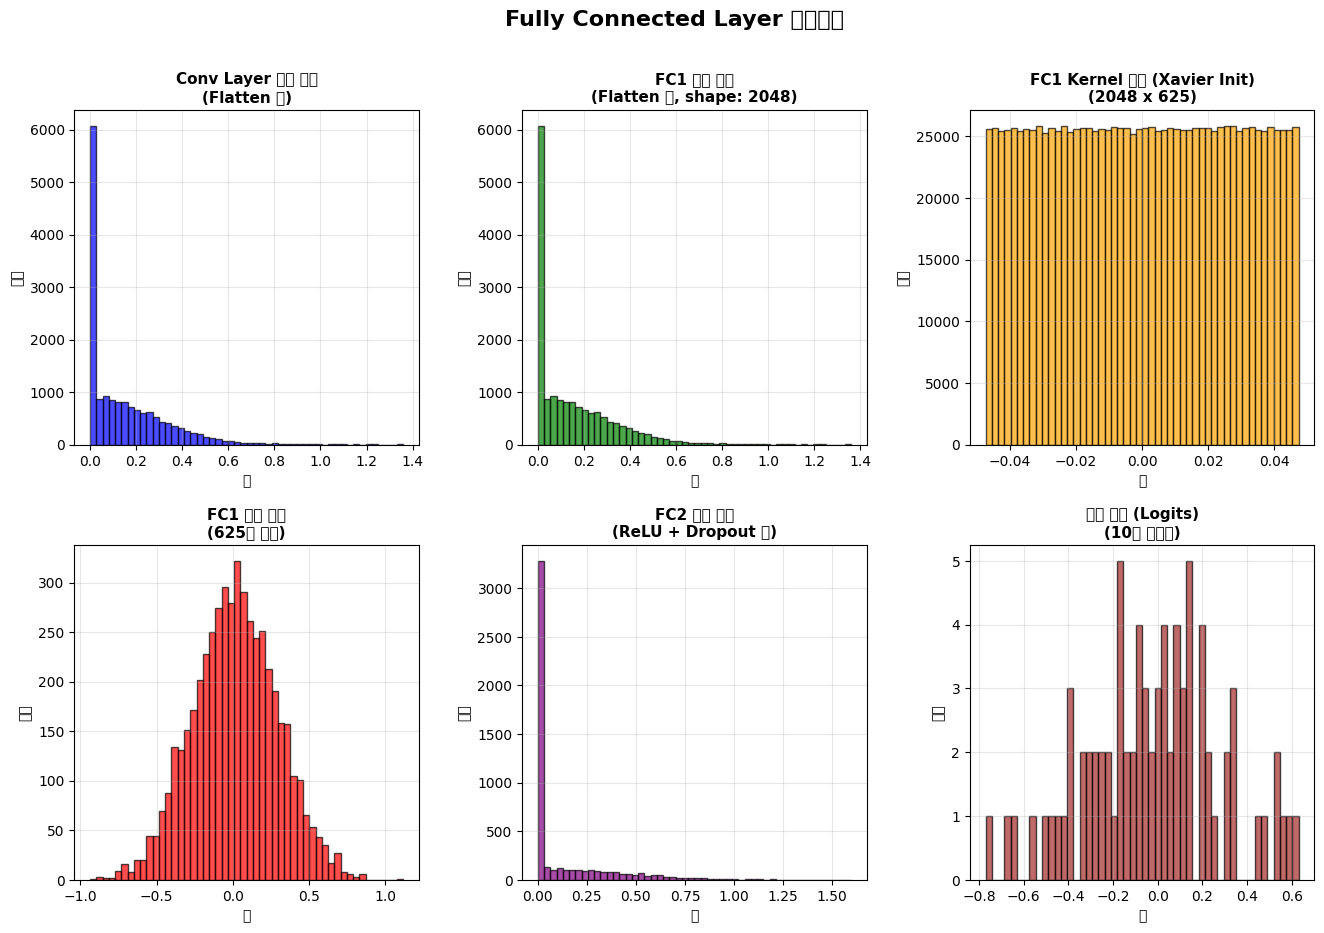

C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\4072403090.py:134: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\4072403090.py:134: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\4072403090.py:134: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\4072403090.py:134: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\4072403090.py:134: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_23508\4072403090.py:134: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missin

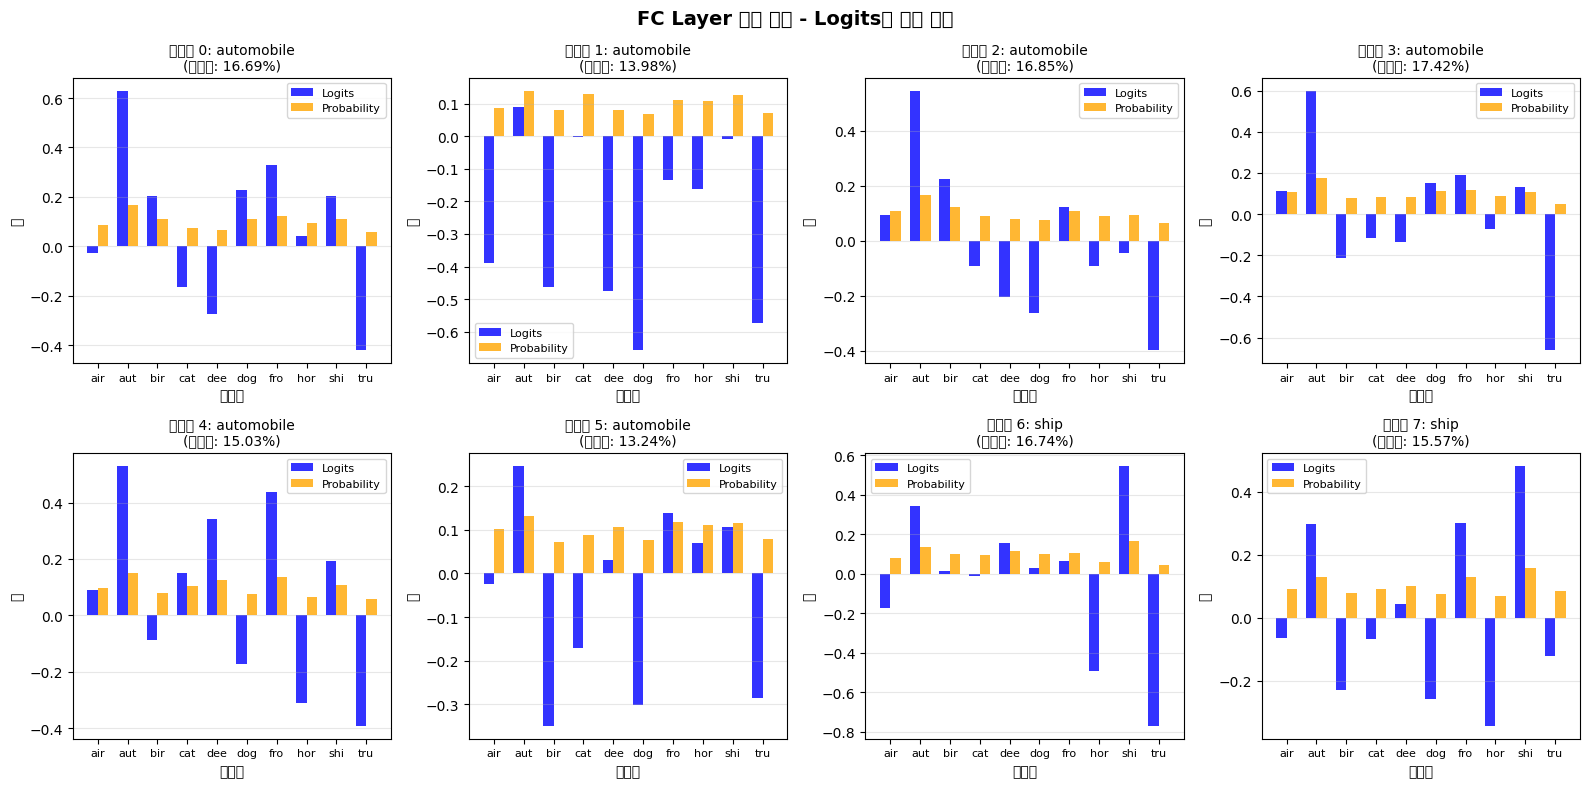


✓ FC Layer 시각화 완료


In [22]:
# FC Layer 출력 시각화
print("=" * 60)
print("Fully Connected Layer 출력 분석")
print("=" * 60)

sample_input, sample_labels = next(iter(data_loader))
sample_input = sample_input[:8].to(device)  # 8개 이미지

with torch.no_grad():
    # Conv layers 통과
    conv_out = model.layer1(sample_input)
    conv_out = model.layer2(conv_out)
    conv_out = model.layer3(conv_out)
    
    print(f"\nConv layers 출력: {conv_out.shape}")
    print(f"Flatten 후: {conv_out.shape[0]} x {conv_out.shape[1] * conv_out.shape[2] * conv_out.shape[3]}")
    
    # Flatten
    flattened = conv_out.view(conv_out.size(0), -1)
    print(f"Flattened shape: {flattened.shape}")
    
    # FC1 입력 전
    fc1_input = flattened
    fc1_output = model.fc1(fc1_input)
    print(f"\nFC1 (2048 -> 625) 출력: {fc1_output.shape}")
    
    # ReLU와 Dropout 포함
    fc1_with_activation = model.layer4[0:2](fc1_input)  # FC1 + ReLU (Dropout 제외)
    print(f"FC1 + ReLU 출력: {fc1_with_activation.shape}")
    
    # FC2 입력
    fc2_input = model.layer4(fc1_input)  # FC1 + ReLU + Dropout
    fc2_output = model.fc2(fc2_input)
    print(f"FC2 (625 -> 10) 출력: {fc2_output.shape}")

# FC Layer 프로세스 시각화
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

fig.suptitle('Fully Connected Layer 프로세스', fontsize=16, fontweight='bold')

# 1. Conv 출력 분포
ax1 = fig.add_subplot(gs[0, 0])
conv_out_flat = conv_out.cpu().numpy().flatten()
ax1.hist(conv_out_flat, bins=50, color='blue', alpha=0.7, edgecolor='black')
ax1.set_title(f'Conv Layer 출력 분포\n(Flatten 전)', fontsize=11, fontweight='bold')
ax1.set_xlabel('값')
ax1.set_ylabel('빈도')
ax1.grid(True, alpha=0.3)
print(f"\nConv 출력 통계: μ={conv_out_flat.mean():.4f}, σ={conv_out_flat.std():.4f}")

# 2. FC1 입력 분포
ax2 = fig.add_subplot(gs[0, 1])
fc1_input_flat = flattened.cpu().numpy().flatten()
ax2.hist(fc1_input_flat, bins=50, color='green', alpha=0.7, edgecolor='black')
ax2.set_title(f'FC1 입력 분포\n(Flatten 후, shape: 2048)', fontsize=11, fontweight='bold')
ax2.set_xlabel('값')
ax2.set_ylabel('빈도')
ax2.grid(True, alpha=0.3)
print(f"FC1 입력 통계: μ={fc1_input_flat.mean():.4f}, σ={fc1_input_flat.std():.4f}")

# 3. FC1 가중치 분포
ax3 = fig.add_subplot(gs[0, 2])
fc1_weights = model.fc1.weight.data.cpu().numpy().flatten()
ax3.hist(fc1_weights, bins=50, color='orange', alpha=0.7, edgecolor='black')
ax3.set_title(f'FC1 Kernel 분포 (Xavier Init)\n(2048 x 625)', fontsize=11, fontweight='bold')
ax3.set_xlabel('값')
ax3.set_ylabel('빈도')
ax3.grid(True, alpha=0.3)
print(f"FC1 가중치 통계: μ={fc1_weights.mean():.6f}, σ={fc1_weights.std():.6f}")

# 4. FC1 출력 분포
ax4 = fig.add_subplot(gs[1, 0])
fc1_out_flat = fc1_output.cpu().numpy().flatten()
ax4.hist(fc1_out_flat, bins=50, color='red', alpha=0.7, edgecolor='black')
ax4.set_title(f'FC1 출력 분포\n(625개 뉴런)', fontsize=11, fontweight='bold')
ax4.set_xlabel('값')
ax4.set_ylabel('빈도')
ax4.grid(True, alpha=0.3)
print(f"FC1 출력 통계: μ={fc1_out_flat.mean():.4f}, σ={fc1_out_flat.std():.4f}")

# 5. FC2 입력 분포 (Activation + Dropout 적용)
ax5 = fig.add_subplot(gs[1, 1])
fc2_input_flat = fc2_input.cpu().numpy().flatten()
ax5.hist(fc2_input_flat, bins=50, color='purple', alpha=0.7, edgecolor='black')
ax5.set_title(f'FC2 입력 분포\n(ReLU + Dropout 후)', fontsize=11, fontweight='bold')
ax5.set_xlabel('값')
ax5.set_ylabel('빈도')
ax5.grid(True, alpha=0.3)
print(f"FC2 입력 통계: μ={fc2_input_flat.mean():.4f}, σ={fc2_input_flat.std():.4f}")

# 6. FC2 출력 (최종 Logits)
ax6 = fig.add_subplot(gs[1, 2])
fc2_out_flat = fc2_output.cpu().numpy().flatten()
ax6.hist(fc2_out_flat, bins=50, color='brown', alpha=0.7, edgecolor='black')
ax6.set_title(f'최종 출력 (Logits)\n(10개 클래스)', fontsize=11, fontweight='bold')
ax6.set_xlabel('값')
ax6.set_ylabel('빈도')
ax6.grid(True, alpha=0.3)
print(f"최종 출력 통계: μ={fc2_out_flat.mean():.4f}, σ={fc2_out_flat.std():.4f}")

plt.show()

# FC2 출력 (Logits)과 확률 비교
cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('FC Layer 최종 출력 - Logits와 확률 분포', fontsize=14, fontweight='bold')

softmax = torch.nn.Softmax(dim=1)
probabilities = softmax(fc2_output)

for idx in range(8):
    ax = axes[idx // 4, idx % 4]
    
    logits = fc2_output[idx].cpu().numpy()
    probs = probabilities[idx].cpu().numpy()
    
    x_pos = np.arange(len(cifar_classes))
    width = 0.35
    
    ax.bar(x_pos - width/2, logits, width, label='Logits', alpha=0.8, color='blue')
    ax.bar(x_pos + width/2, probs, width, label='Probability', alpha=0.8, color='orange')
    
    pred_class = np.argmax(logits)
    ax.set_title(f'이미지 {idx}: {cifar_classes[pred_class]}\n(신뢰도: {probs[pred_class]:.2%})', fontsize=10)
    ax.set_xlabel('클래스')
    ax.set_ylabel('값')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([c[:3] for c in cifar_classes], fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ FC Layer 시각화 완료")

In [23]:
# 학습 loss 기록용 리스트
train_losses = []

for epoch in range(training_epochs):
    avg_cost = 0

    for X, Y in data_loader: # 미니 배치 단위로 꺼내온다. X는 미니 배치, Y는 레이블.
        
        X = X.to(device)
        Y = Y.to(device)

        optimizer.zero_grad()
        hypothesis = model(X)
        cost = criterion(hypothesis, Y)
        cost.backward()
        optimizer.step()

        avg_cost += cost / total_batch

    # loss 기록
    train_losses.append(avg_cost.item())
    print('[Epoch: {:>4}] cost = {:>.9}'.format(epoch + 1, avg_cost))

[Epoch:    1] cost = 1.60012698
[Epoch:    2] cost = 1.2622776
[Epoch:    3] cost = 1.11301756
[Epoch:    4] cost = 1.01910329
[Epoch:    5] cost = 0.954457521
[Epoch:    6] cost = 0.905840278
[Epoch:    7] cost = 0.871646702
[Epoch:    8] cost = 0.840485215
[Epoch:    9] cost = 0.808492541
[Epoch:   10] cost = 0.792601287
[Epoch:   11] cost = 0.769172788
[Epoch:   12] cost = 0.756025672
[Epoch:   13] cost = 0.748754025
[Epoch:   14] cost = 0.731004953
[Epoch:   15] cost = 0.72146529
[Epoch:   16] cost = 0.708243608
[Epoch:   17] cost = 0.699992597
[Epoch:   18] cost = 0.688089252
[Epoch:   19] cost = 0.682637691
[Epoch:   20] cost = 0.674471438


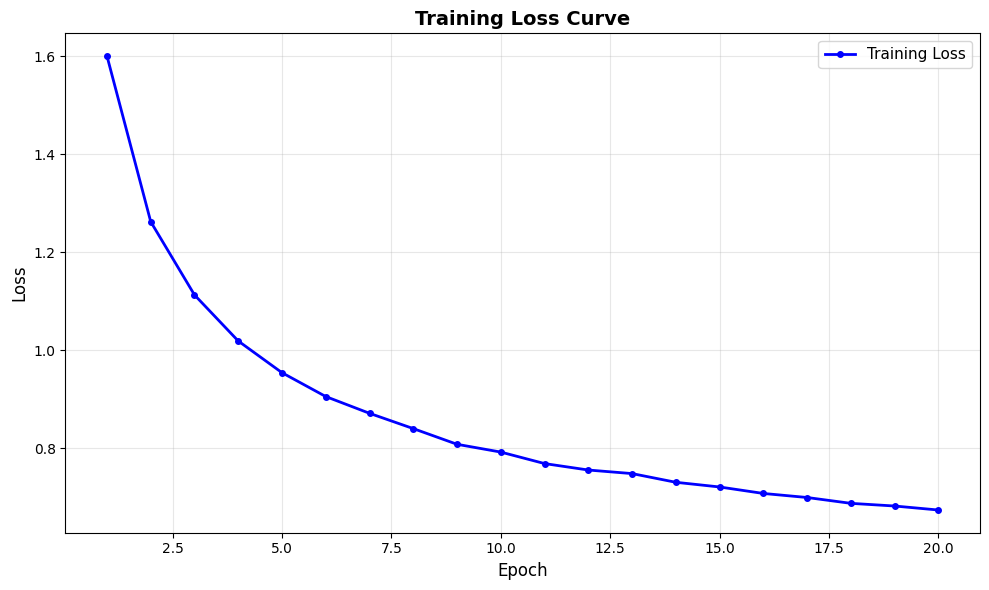


초기 Loss: 1.6001
최종 Loss: 0.6745
Loss 감소량: 0.9257


In [24]:
# 학습 곡선 시각화
plt.figure(figsize=(10, 6))
plt.plot(range(1, training_epochs + 1), train_losses, 'b-', label='Training Loss', linewidth=2, marker='o', markersize=4)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training Loss Curve', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n초기 Loss: {train_losses[0]:.4f}')
print(f'최종 Loss: {train_losses[-1]:.4f}')
print(f'Loss 감소량: {train_losses[0] - train_losses[-1]:.4f}')

In [25]:
# 테스트
with torch.no_grad():
    X_test = torch.tensor(cifar_test.data).permute(0, 3, 1, 2).float().to(device)
    Y_test = torch.tensor(cifar_test.targets).to(device)

    prediction = model(X_test)

    correct_prediction = torch.argmax(prediction, 1) == Y_test 

    accuracy = correct_prediction.float().mean()
    print('Accuracy : ', accuracy.item()*100)

Accuracy :  41.359999775886536


In [ ]:
# 정확도 향상 방법
# 1. Epochs 증가
# 2. Batch size 늘리기
# 3. Data normalization
